In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix

In [11]:
df = pd.read_csv('house prediction.csv')
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [9]:
df.columns.tolist()

['date',
 'price',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'street',
 'city',
 'statezip',
 'country']

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [12]:
df.isna().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [15]:
df.nunique()

date               70
price            1741
bedrooms           10
bathrooms          26
sqft_living       566
sqft_lot         3113
floors              6
waterfront          2
view                5
condition           5
sqft_above        511
sqft_basement     207
yr_built          115
yr_renovated       60
street           4525
city               44
statezip           77
country             1
dtype: int64

In [16]:
df.shape

(4600, 18)

In [17]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [23]:
print(f'Min price: {df['price'].min()}')
print(f'Mean price: {df['price'].mean()}')
print(f'Max price: {df['price'].max()}')

Min price: 0.0
Mean price: 551962.9884732141
Max price: 26590000.0


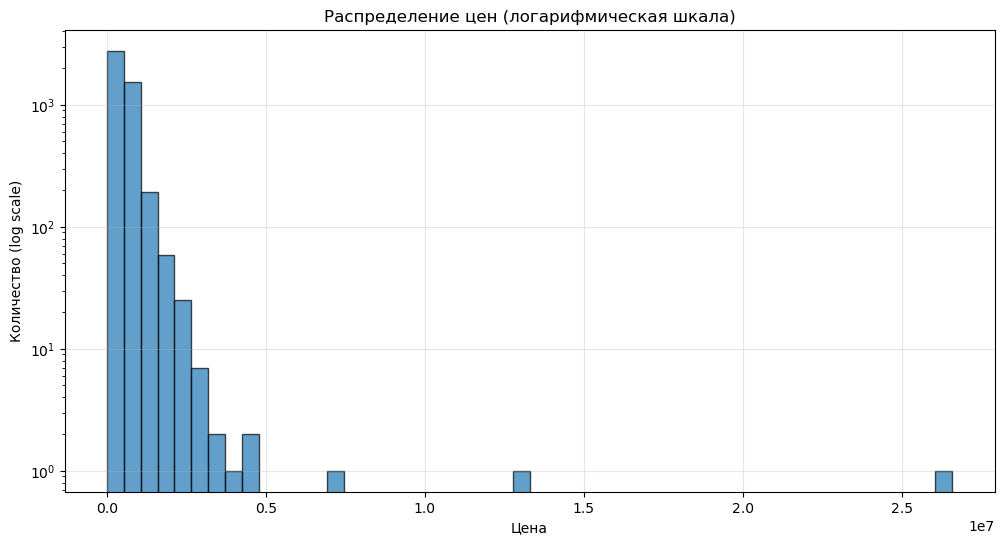

In [12]:
plt.figure(figsize=(12, 6))
plt.hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
plt.yscale('log')
plt.title('Распределение цен (логарифмическая шкала)')
plt.xlabel('Цена')
plt.ylabel('Количество (log scale)')
plt.grid(alpha=0.3)
plt.show()

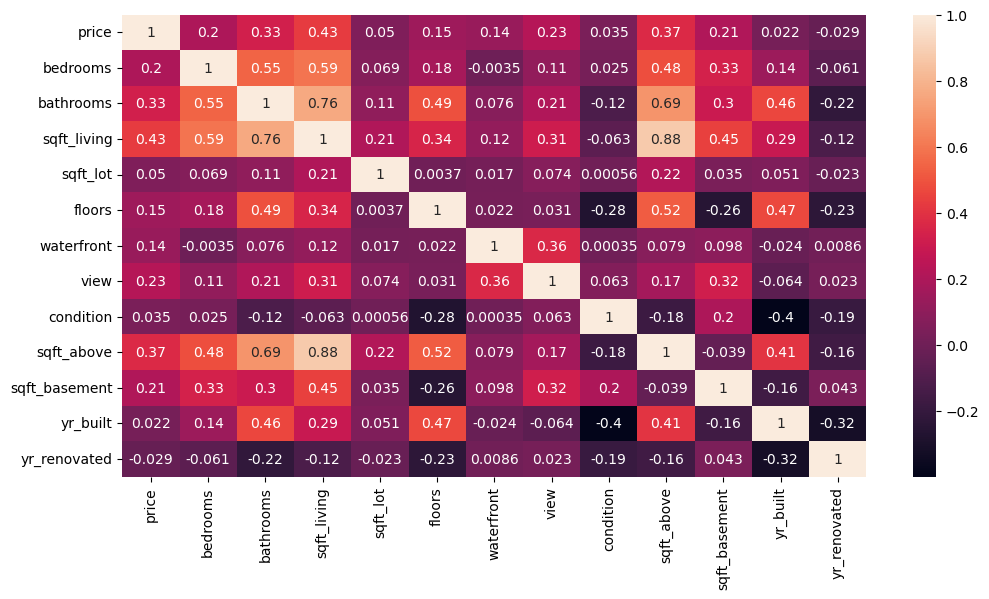

In [16]:
plt.figure(figsize=(12,6))
cm = df.drop(['date', 'street', 'city', 'statezip', 'country'], axis=1).corr()
sns.heatmap(cm, annot=True)
plt.show()

In [3]:
selected_features = ['price', 'sqft_living', 'bedrooms', 'bathrooms', 'sqft_lot', 'waterfront']
correlation_matrix = df[selected_features].corr()
correlation_matrix['price']

price          1.000000
sqft_living    0.430410
bedrooms       0.200336
bathrooms      0.327110
sqft_lot       0.050451
waterfront     0.135648
Name: price, dtype: float64

<Axes: xlabel='sqft_living', ylabel='price'>

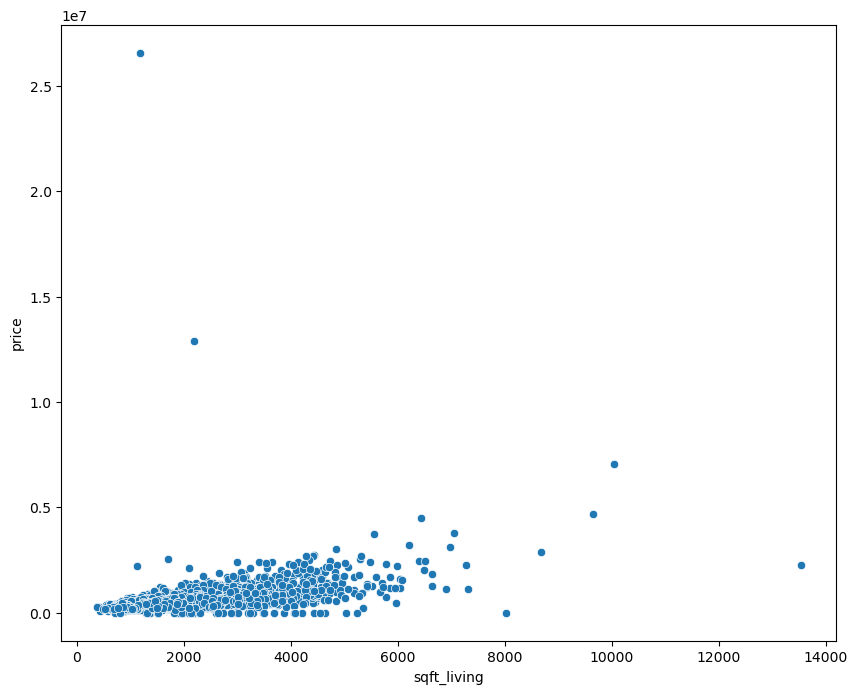

In [22]:
plt.figure(figsize=(10,8))
sns.scatterplot(x=df['sqft_living'], y=df['price'])

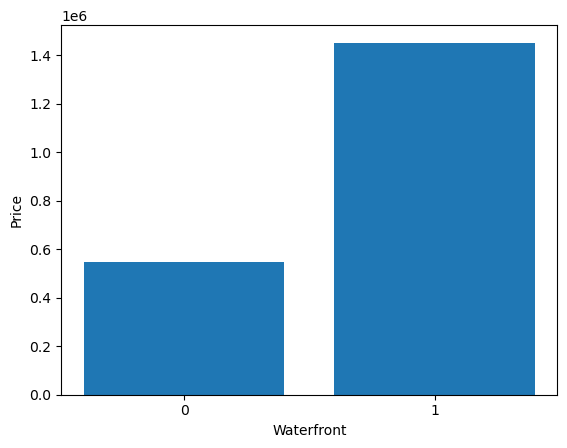

In [28]:
plt.bar(df['waterfront'].unique(), df.groupby('waterfront')['price'].mean())
plt.xticks([0, 1])  # Явно задаем метки на оси X
plt.xlabel('Waterfront')
plt.ylabel('Price')
plt.show()

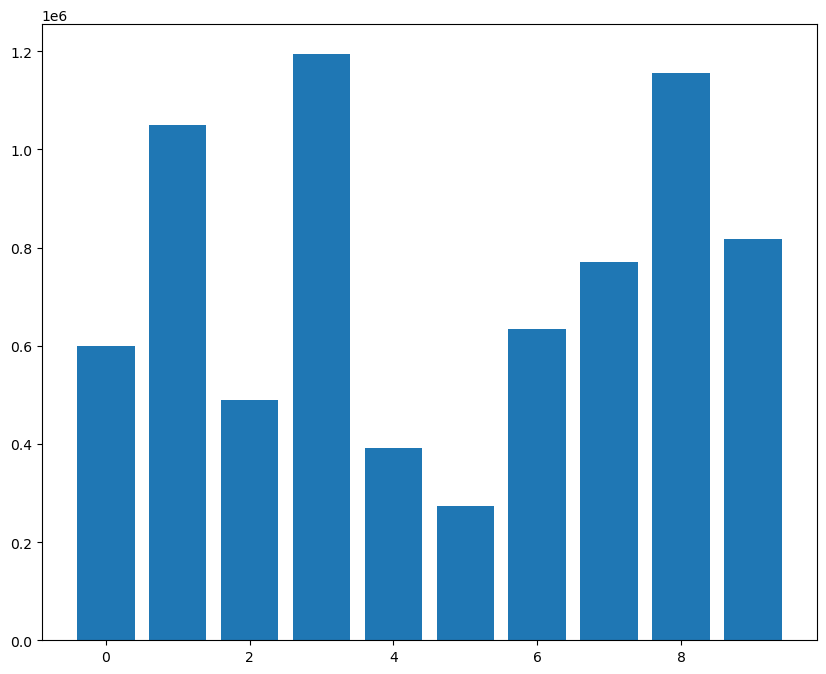

In [31]:
plt.figure(figsize=(10,8))
plt.bar(df['bedrooms'].unique(), df.groupby('bedrooms')['price'].mean())
plt.show()

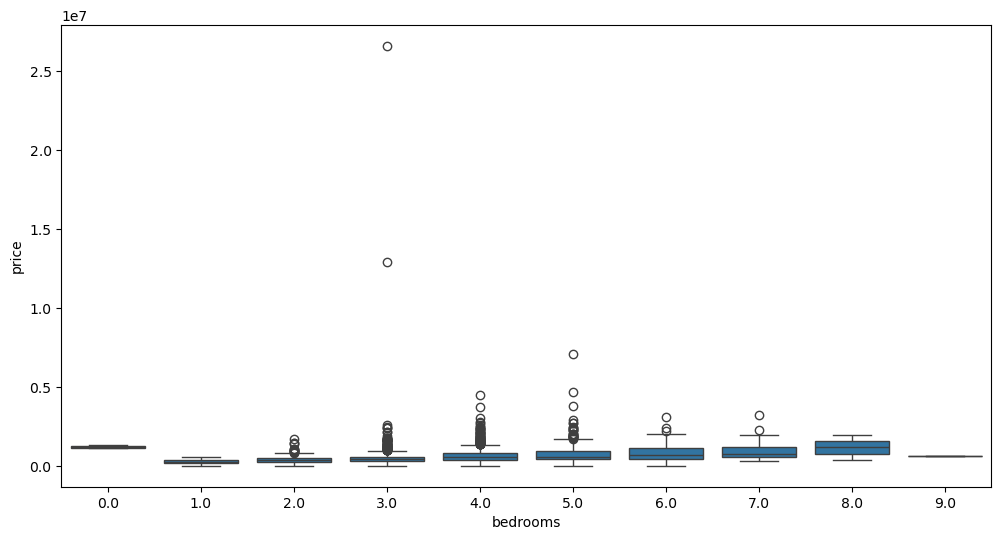

In [33]:
plt.figure(figsize=(12, 6)) 
sns.boxplot(x='bedrooms', y='price', data=df)
plt.show()

In [19]:
def remove_outliers(df, column, threshold = 3):
    median = df[column].median()
    mad = np.median(np.abs(df[column] - median))
    modified_z_scores = 0.6745 * (df[column] - median) / mad
    return df[np.abs(modified_z_scores) < threshold]
df = remove_outliers(df, 'price', threshold=3)
df = remove_outliers(df, 'sqft_living', threshold=3)
df = remove_outliers(df, 'bedrooms', threshold=3)
df.shape

(4246, 18)

In [23]:
df.dtypes

date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street            object
city              object
statezip          object
country           object
dtype: object

In [34]:
df_encoded = df.copy()
le = LabelEncoder()
df_encoded['city'] = le.fit_transform(df_encoded['city'])
df_encoded = df_encoded.drop(['date', 'street', 'statezip', 'country'], axis = 1)
df_encoded.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,36
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,18
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,3
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,31
5,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,35


In [49]:
x = df_encoded.drop(['price','yr_built', 'yr_renovated'], axis = 1)
y = df_encoded['price']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
lr = LinearRegression()
lr_model = lr.fit(x_train, y_train)
lr_model

LinearRegression()

In [50]:
rf = RandomForestRegressor()
rf_model = rf.fit(x_train, y_train)
rf_model

RandomForestRegressor()

In [51]:
gb = GradientBoostingRegressor()
gb_model = gb.fit(x_train, y_train)
gb_model

GradientBoostingRegressor()

In [52]:
y_predlr = lr_model.predict(x_test)
y_predgb = gb_model.predict(x_test)
y_predrf = rf_model.predict(x_test)
predictions = [y_predlr, y_predgb, y_predrf]

for i, y_pred in enumerate(predictions):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f'Model: {i+1}')
    print(f'MAE:{mae:}')
    print(f'MSE:{mse}')
    print(f'R2:{r2}')

#rfr наилучшая. далее работаем с ней

Model: 1
MAE:126663.3451215979
MSE:26340877866.12933
R2:0.4372344730795892
Model: 2
MAE:95814.85065756361
MSE:18530737591.02606
R2:0.6040959470812786
Model: 3
MAE:91509.8183473389
MSE:18046468217.394794
R2:0.6144422275130881


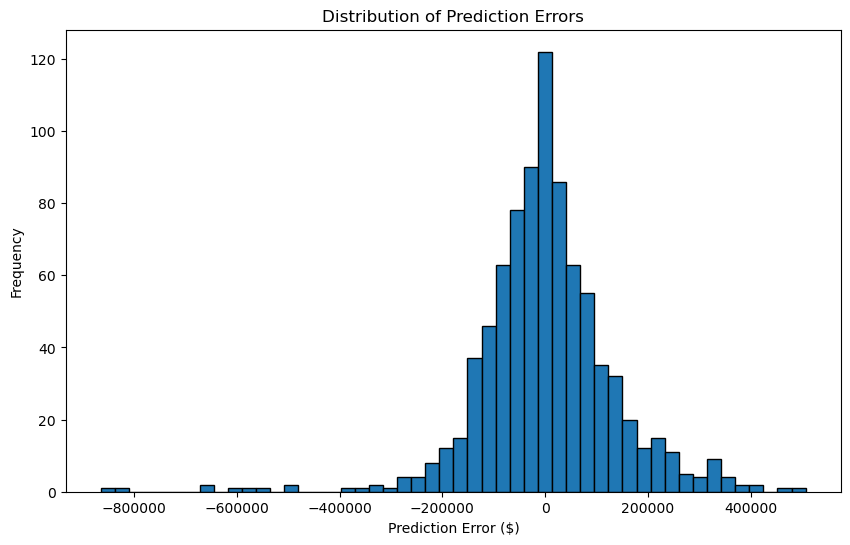

In [58]:
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=50, edgecolor='black')
plt.xlabel('Prediction Error ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.show()

In [70]:
importances = rf_model.feature_importances_
feature_names = x.columns.tolist()

feat_imprf = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Самые важные признаки:")
print(feat_imprf)

Самые важные признаки:
          feature  importance
2     sqft_living    0.401233
10           city    0.218387
3        sqft_lot    0.130863
8      sqft_above    0.083289
1       bathrooms    0.044499
0        bedrooms    0.029747
9   sqft_basement    0.029290
7       condition    0.024160
6            view    0.020609
4          floors    0.014723
5      waterfront    0.003200
